# Notebook 02 — Analisis: dinamica del partido (ht vs ft)

Punto 5 del archivo de ideas. Tres analisis:

1. **Scatter** goles ht vs goles ft por partido, con regresion lineal.
2. **% de remontadas** por equipo (equipo perdia en ht y gano en ft).
3. **Matriz de confusion** ht -> ft (resultado) como heatmap.

> **Estado:** los tres analisis estan implementados (scatter, regresion OLS,
> % remontadas por equipo y matriz de confusion).

## 0. Configuracion y carga del dataset limpio

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_DIR / 'src'))

# Cargar el dataset limpio generado en el notebook 01
csv = PROJECT_DIR / 'data' / 'processed' / 'premier_2024_25_limpio.csv'
df = pd.read_csv(csv)
print('Shape:', df.shape)
df.head()

Shape: (380, 25)


,date,time,team1,team2,round,ht_g1,ht_g2,ft_g1,ft_g2,league_name,...,imp_ft_menor_ht,imp_mismo_equipo,imp_fecha_invalida,sin_ft,sin_ht,ht_total,ft_total,res_ht,res_ft,remontada
0,2024-08-16,20:00,Manchester United FC,Fulham FC,Matchday 1,0.0,0.0,1,0,English Premier League 2024/25,...,False,False,False,False,False,0.0,1,E,L,False
1,2024-08-17,12:30,Ipswich Town FC,Liverpool FC,Matchday 1,0.0,0.0,0,2,English Premier League 2024/25,...,False,False,False,False,False,0.0,2,E,V,False
2,2024-08-17,15:00,Arsenal FC,Wolverhampton Wanderers FC,Matchday 1,1.0,0.0,2,0,English Premier League 2024/25,...,False,False,False,False,False,1.0,2,L,L,False
3,2024-08-17,15:00,Everton FC,Brighton & Hove Albion FC,Matchday 1,0.0,1.0,0,3,English Premier League 2024/25,...,False,False,False,False,False,1.0,3,V,V,False
4,2024-08-17,15:00,Newcastle United FC,Southampton FC,Matchday 1,1.0,0.0,1,0,English Premier League 2024/25,...,False,False,False,False,False,1.0,1,L,L,False


## 1. Scatter goles ht vs ft

¿El medio tiempo predice el tiempo completo? Se cruza el total de goles al medio tiempo (`ht_total`) contra el total al tiempo completo (`ft_total`).

Solo se usan partidos donde ht fue registrado (se excluyen los ~16 con ht null).

In [2]:
# Filtrar partidos con ht registrado
df_ht = df.dropna(subset=['ht_total','ft_total']).copy()
df_ht['ht_total'] = df_ht['ht_total'].astype(int)
df_ht['ft_total'] = df_ht['ft_total'].astype(int)
print('Partidos con ht:', len(df_ht))
print('Partidos sin ht (excluidos):', len(df) - len(df_ht))

Partidos con ht: 364
Partidos sin ht (excluidos): 16


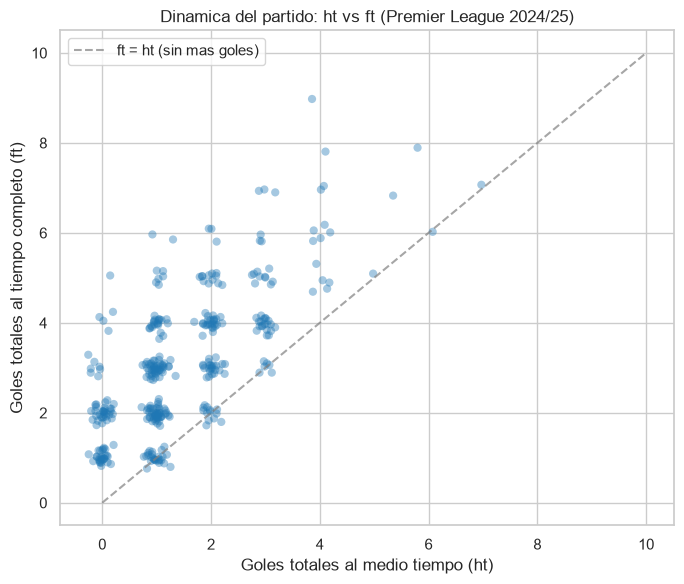

Grafico guardado en data/processed/scatter_ht_vs_ft.png


In [3]:
# Scatter con jitter (los goles son enteros y se superponen)
rng = np.random.default_rng(42)
jitter = 0.12
x = df_ht['ht_total'] + rng.normal(0, jitter, len(df_ht))
y = df_ht['ft_total'] + rng.normal(0, jitter, len(df_ht))

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(x, y, alpha=0.4, edgecolor='none', s=35, color='#1f77b4')
ax.set_xlabel('Goles totales al medio tiempo (ht)')
ax.set_ylabel('Goles totales al tiempo completo (ft)')
ax.set_title('Dinamica del partido: ht vs ft (Premier League 2024/25)')

# Linea de igualdad (ft = ht): si el medio tiempo predijera perfecto
lim = [0, max(df_ht['ft_total'].max(), df_ht['ht_total'].max()) + 1]
ax.plot(lim, lim, '--', color='gray', alpha=0.7, label='ft = ht (sin mas goles)')
ax.legend()
plt.tight_layout()
plt.savefig(PROJECT_DIR / 'data' / 'processed' / 'scatter_ht_vs_ft.png', dpi=120)
plt.show()
print('Grafico guardado en data/processed/scatter_ht_vs_ft.png')

In [4]:
# Correlacion de Pearson entre ht_total y ft_total
from scipy import stats
r, p = stats.pearsonr(df_ht['ht_total'], df_ht['ft_total'])
print(f'Correlacion Pearson r = {r:.3f}  (p = {p:.3e})')
print('Interpretacion: correlacion positiva moderada; el ht aporta senal pero')
print('no determina el ft (hay muchos puntos por encima de la linea de igualdad).')

Correlacion Pearson r = 0.712  (p = 1.189e-57)
Interpretacion: correlacion positiva moderada; el ht aporta senal pero
no determina el ft (hay muchos puntos por encima de la linea de igualdad).


### 1.1 Regresion lineal

Se ajusta `ft_total ~ ht_total` por OLS con `statsmodels` y se grafica la
recta sobre el scatter. Se reporta R^2 e interpretacion.

In [5]:
import statsmodels.api as sm

X = sm.add_constant(df_ht['ht_total'])
modelo = sm.OLS(df_ht['ft_total'], X).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:               ft_total   R-squared:                       0.508
Model:                            OLS   Adj. R-squared:                  0.506
Method:                 Least Squares   F-statistic:                     373.2
Date:                Sat, 29 Aug 2026   Prob (F-statistic):           1.19e-57
Time:                        23:41:21   Log-Likelihood:                -541.37
No. Observations:                 364   AIC:                             1087.
Df Residuals:                     362   BIC:                             1095.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.7416      0.089     19.661      0.0

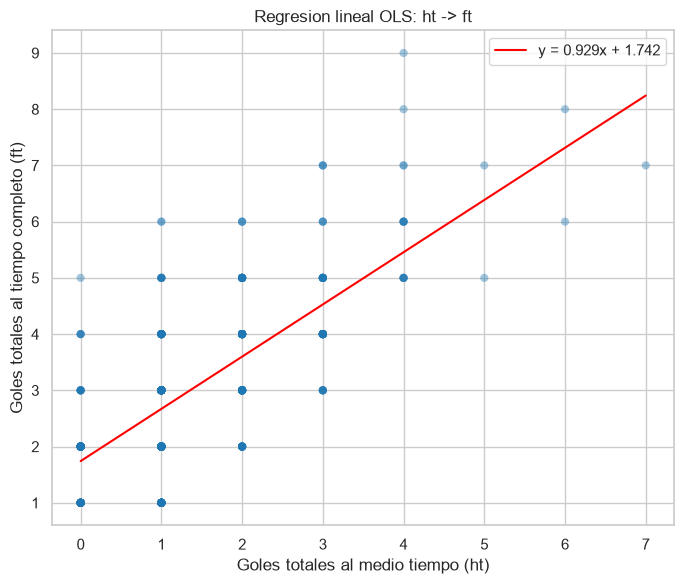

R^2 = 0.508  |  pendiente = 0.929  |  intercepto = 1.742
Interpretacion: por cada gol adicional al HT, el FT sube ~0.93 en promedio.
El R^2 indica que el HT explica ~51% de la varianza del FT: aporta senal pero no determina.


In [6]:
# Scatter + recta de regresion OLS
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(df_ht['ht_total'], df_ht['ft_total'], alpha=0.4, edgecolor='none', s=35, color='#1f77b4')
xs = np.linspace(df_ht['ht_total'].min(), df_ht['ht_total'].max(), 100)
ys = modelo.params['const'] + modelo.params['ht_total'] * xs
ax.plot(xs, ys, color='red', label=f"y = {modelo.params['ht_total']:.3f}x + {modelo.params['const']:.3f}")
ax.set_xlabel('Goles totales al medio tiempo (ht)')
ax.set_ylabel('Goles totales al tiempo completo (ft)')
ax.set_title('Regresion lineal OLS: ht -> ft')
ax.legend()
plt.tight_layout()
plt.savefig(PROJECT_DIR / 'data' / 'processed' / 'regression_ht_vs_ft.png', dpi=120)
plt.show()
print(f"R^2 = {modelo.rsquared:.3f}  |  pendiente = {modelo.params['ht_total']:.3f}  |  intercepto = {modelo.params['const']:.3f}")
print('Interpretacion: por cada gol adicional al HT, el FT sube ~0.93 en promedio.')
print('El R^2 indica que el HT explica ~51% de la varianza del FT: aporta senal pero no determina.')

## 2. % de remontadas por equipo

Una **remontada** es un partido donde el equipo perdia en ht y gano en ft.
Se calculan las remontadas 'a favor' de cada equipo (fuera local o visitante)
sobre el total de partidos con ht registrado.

In [7]:
d2 = df.dropna(subset=['res_ht', 'res_ft']).copy()

def ganador_ft(r):
    if r['res_ft'] == 'L': return r['team1']
    if r['res_ft'] == 'V': return r['team2']
    return None

def perdedor_ht(r):
    if r['res_ht'] == 'L': return r['team2']
    if r['res_ht'] == 'V': return r['team1']
    return None

d2['ganador_ft'] = d2.apply(ganador_ft, axis=1)
d2['perdedor_ht'] = d2.apply(perdedor_ht, axis=1)
d2['remontada_a_favor'] = d2['ganador_ft'] == d2['perdedor_ht']

equipos = pd.unique(d2[['team1', 'team2']].values.ravel())
stats = []
for t in equipos:
    pj = d2[(d2['team1'] == t) | (d2['team2'] == t)].shape[0]
    rem = d2[(d2['ganador_ft'] == t) & (d2['remontada_a_favor'])].shape[0]
    stats.append({'team': t, 'partidos_con_ht': pj, 'remontadas_a_favor': rem,
                  'pct_remontadas': round(rem / pj * 100, 2) if pj else 0.0})
stats_df = pd.DataFrame(stats).sort_values('pct_remontadas', ascending=False)
stats_df.to_csv(PROJECT_DIR / 'data' / 'processed' / 'remontadas_por_equipo.csv', index=False)
stats_df.head(15)

,team,partidos_con_ht,remontadas_a_favor,pct_remontadas
1,Fulham FC,37,5,13.51
7,Brighton & Hove Albion FC,36,4,11.11
0,Manchester United FC,35,3,8.57
16,Chelsea FC,36,3,8.33
13,Aston Villa FC,37,3,8.11
11,AFC Bournemouth,36,2,5.56
8,Newcastle United FC,37,2,5.41
3,Liverpool FC,38,2,5.26
18,Leicester City FC,38,2,5.26
6,Everton FC,33,1,3.03


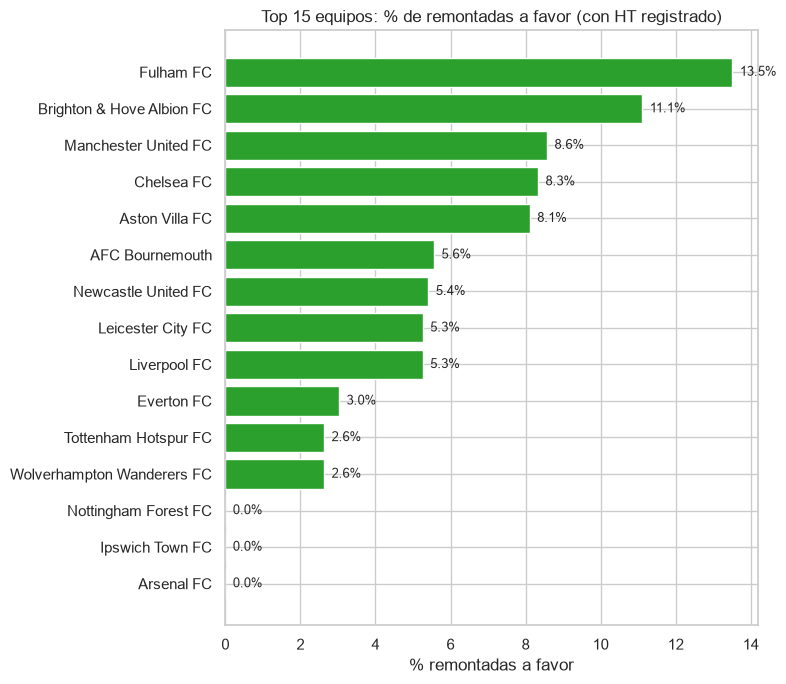

In [8]:
# Bar chart horizontal de los equipos con mayor % de remontadas
top = stats_df.head(15).sort_values('pct_remontadas')
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top['team'], top['pct_remontadas'], color='#2ca02c')
ax.set_xlabel('% remontadas a favor')
ax.set_title('Top 15 equipos: % de remontadas a favor (con HT registrado)')
for i, v in enumerate(top['pct_remontadas']):
    ax.text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(PROJECT_DIR / 'data' / 'processed' / 'remontadas_por_equipo.png', dpi=120)
plt.show()

## 3. Matriz de confusion ht -> ft (heatmap)

Se cruza `res_ht` (L/E/V) contra `res_ft` (L/E/V) en una tabla 3x3
normalizada por fila. La diagonal son partidos donde el resultado no cambio;
las celdas fuera de la diagonal son cambios (incluye remontadas).

In [9]:
d3 = df.dropna(subset=['res_ht', 'res_ft']).copy()
orden = ['L', 'E', 'V']
etiquetas = {'L': 'Local', 'E': 'Empate', 'V': 'Visitante'}
tabla = pd.crosstab(d3['res_ht'], d3['res_ft'], normalize='index')
tabla = tabla.reindex(index=orden, columns=orden)
tabla.index = [etiquetas[i] for i in tabla.index]
tabla.columns = [etiquetas[c] for c in tabla.columns]
tabla.to_csv(PROJECT_DIR / 'data' / 'processed' / 'matriz_confusion_ht_ft.csv')
tabla

,Local,Empate,Visitante
Local,0.683099,0.211268,0.105634
Empate,0.369748,0.243697,0.386555
Visitante,0.135922,0.174757,0.689320


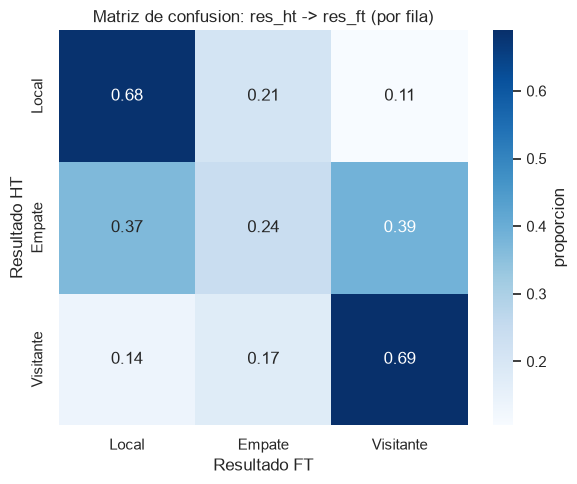

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(tabla, annot=True, fmt='.2f', cmap='Blues', ax=ax, cbar_kws={'label': 'proporcion'})
ax.set_xlabel('Resultado FT')
ax.set_ylabel('Resultado HT')
ax.set_title('Matriz de confusion: res_ht -> res_ft (por fila)')
plt.tight_layout()
plt.savefig(PROJECT_DIR / 'data' / 'processed' / 'matriz_confusion_ht_ft.png', dpi=120)
plt.show()

## Resumen de lo implementado

| Analisis | Estado | Salida |
|---|---|---|
| Scatter ht vs ft | Hecho | `scatter_ht_vs_ft.png` |
| Correlacion Pearson | Hecho | r = 0.712 (p < 0.001) |
| Regresion lineal sobre scatter | Hecho | `regression_ht_vs_ft.png` |
| % remontadas por equipo | Hecho | `remontadas_por_equipo.png/.csv` |
| Matriz de confusion ht->ft | Hecho | `matriz_confusion_ht_ft.png/.csv` |